# What explains solar curtailment: load, wind and the ONS day-ahead plan

Data loaded by `terra_energy_research.ons` and organized in `sql/20_clean_system.sql`:
- **Scheduled and verified load** per subsystem, 30 min (ONS load API).
- **Verified energy balance** per subsystem: wind, solar, hydro, thermal and load, hourly.
- **Daily schedule** (from Oct 2024): scheduled generation per plant and **forecast vs. scheduled** for
  wind and solar. Published around 23:00 on the day before, ahead of operation.

**Definitions**
- *Forecast net load* = scheduled load − wind forecast − centralized solar forecast − scheduled
  distributed solar.
- *Planned curtailment* = forecast − scheduled, summed when positive.
- *Curtailed share* = `curtailment / (generation + curtailment)`, as in notebook 01.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from terra_energy_research import viz
from terra_energy_research.db import query

viz.setup()
pd.set_option("display.float_format", "{:,.2f}".format)

MW_HALFHOUR_TO_GWH = 1 / 2000  # sum of 30-min powers (MW) -> energy (GWh)

## 1. Coverage and quality of the sources

Files loaded per source, schedule units linked to clusters, and days on which the daily schedule came
with renewables set to zero.

In [2]:
coverage = query("""
    select dataset, count(*) as files, min(period) as first, max(period) as last, sum(row_count) as rows
    from br.source_file
    where dataset in ('load_programmed', 'load_verified', 'subsystem_balance', 'program_daily', 'renewable_program')
    group by 1
    order by 1
""")
program_units = query("""
    select gen_type,
           count(*)       as pdp_units,
           count(id_ons)  as linked_to_cluster,
           round(avg(days_matched::numeric / nullif(days_seen, 0)), 2) as matched_day_fraction
    from br.program_unit
    group by 1
""")
solar_units_with_plan = query("""
    select (select count(distinct id_ons) from br.pv_curtail)                              as clusters,
           (select count(distinct id_ons) from br.program_unit where id_ons is not null)  as with_plan
""")
days_with_zero_renewables = query("""
    select count(*) as days_with_renewable_schedule_zeroed
    from (select instante::date, sum(programmed_mw) as total
          from br.program_daily_agg
          where gen_type in ('SOLAR', 'EÓLICA') and modality <> 'TIPO III'
          group by 1
          having sum(programmed_mw) = 0) as zeroed
""")
display(coverage, program_units, solar_units_with_plan, days_with_zero_renewables)

,dataset,files,first,last,rows
0,load_programmed,29,2024-04,2026-08,"169,440.00"
1,load_verified,29,2024-04,2026-08,"169,536.00"
2,program_daily,698,2024-10-01,2026-08-31,"132,304,752.00"
3,renewable_program,698,2024-10-01,2026-08-31,"18,044,832.00"
4,subsystem_balance,3,2024,2026,"105,960.00"


,gen_type,pdp_units,linked_to_cluster,matched_day_fraction
0,SOLAR,103,103,0.99
1,EÓLICA,195,195,0.99


,clusters,with_plan
0,87,255


,days_with_renewable_schedule_zeroed
0,1


## 2. Daily curtailment × forecast net load

One point per day: SIN average between 9:00 and 14:59.

In [3]:
daily = query("""
    with curtailment as (
        select instante::date as day,
               100 * sum(curtailed_mw) / nullif(sum(generation) + sum(curtailed_mw), 0) as curtailed_share
        from clean.pv_curtail
        where extract(hour from instante) between 9 and 14
        group by 1
    ), system as (
        -- 12 half-hour intervals between 9:00 and 14:59: sum / 12 = average over the window (MW)
        select instante::date as day,
               sum(load_programmed) / 12 as scheduled_load,
               sum(load_programmed - coalesce(wind_forecast, 0) - coalesce(solar_forecast, 0)
                   - coalesce(solar_distributed_programmed, 0)) / 12 as forecast_net_load,
               sum(net_load_verified) / 12 as verified_net_load,
               bool_or(wind_forecast is not null) as has_forecast
        from clean.system_halfhour
        where extract(hour from instante) between 9 and 14
        group by 1
    )
    select c.day, c.curtailed_share, s.scheduled_load, s.forecast_net_load, s.verified_net_load, s.has_forecast
    from curtailment c
    join system s using (day)
""")
daily["day"] = pd.to_datetime(daily["day"])
daily["weekend"] = daily["day"].dt.dayofweek >= 5
print(f"{len(daily)} days; {daily['has_forecast'].sum()} with renewable forecasts")

883 days; 698 with renewable forecasts


In [4]:
# Only days with renewable forecasts: before Oct 2024 the "forecast net load" would be just the scheduled
# load (missing forecasts count as zero), which would mix two different variables.
days = daily[daily["has_forecast"]].copy()
days["net_load_gw"] = days["forecast_net_load"] / 1000  # MW -> GW
print(f"{len(days)} days ({days['day'].min():%Y-%m-%d} to {days['day'].max():%Y-%m-%d}); "
      f"{days['weekend'].sum()} on Saturday or Sunday")

# Spearman correlation between the curtailed share and the day's loads
display(days[["curtailed_share", "scheduled_load", "forecast_net_load", "verified_net_load"]].corr(
    method="spearman").round(2))

# net-load deciles: mean curtailed share and median net load per decile
days["decile"] = pd.qcut(days["net_load_gw"], 10, labels=range(1, 11))
by_decile = days.groupby("decile", observed=True).agg(
    net_load_gw=("net_load_gw", "median"),
    curtailed_share=("curtailed_share", "mean"),
    days=("day", "size"),
)
by_decile

698 days (2024-10-01 to 2026-08-31); 200 on Saturday or Sunday

,curtailed_share,scheduled_load,forecast_net_load,verified_net_load
curtailed_share,1.00,-0.62,-0.77,-0.60
scheduled_load,-0.62,1.00,0.87,0.86
forecast_net_load,-0.77,0.87,1.00,0.91
verified_net_load,-0.60,0.86,0.91,1.00


,net_load_gw,curtailed_share,days
decile,,,
1,22.88,60.16,70
2,30.56,45.84,70
3,34.46,35.93,70
4,37.37,28.96,69
5,39.75,25.99,70
6,43.07,21.93,70
7,46.37,17.14,69
8,51.34,13.34,70
9,55.04,11.56,70


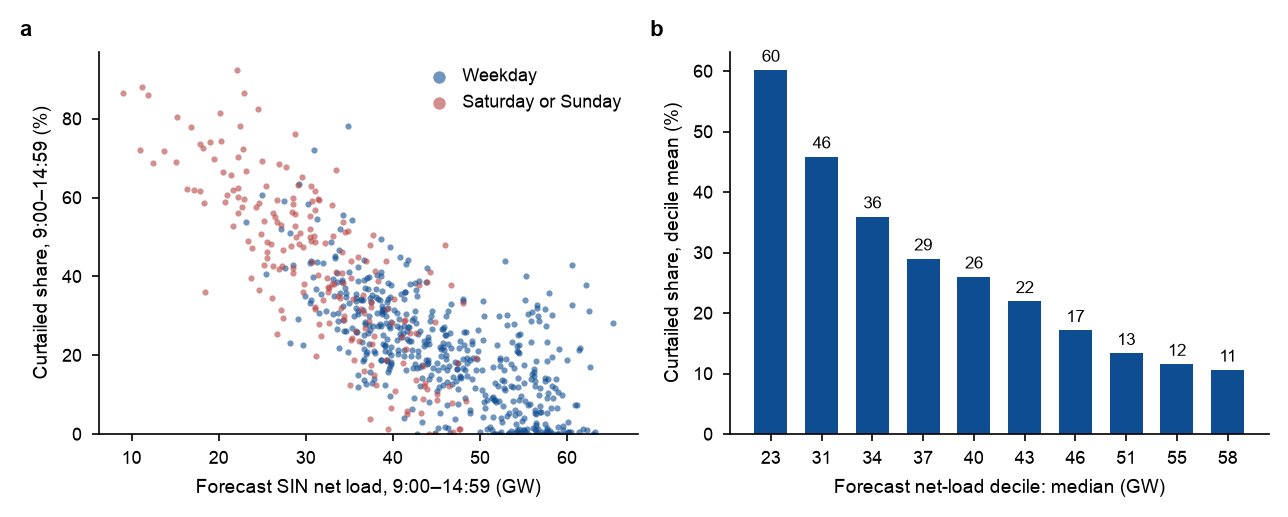

In [5]:
fig, (ax_days, ax_deciles) = plt.subplots(1, 2, figsize=viz.size(height_mm=62), layout="constrained")

# a: one point per day
for weekend, color, label in ((False, viz.WEEKDAY_COLOR, "Weekday"), (True, viz.WEEKEND_COLOR, "Saturday or Sunday")):
    part = days[days["weekend"] == weekend]
    ax_days.scatter(part["net_load_gw"], part["curtailed_share"], s=5, color=color, alpha=0.6,
                    linewidths=0, label=label)
ax_days.set_xlabel("Forecast SIN net load, 9:00–14:59 (GW)")
ax_days.set_ylabel("Curtailed share, 9:00–14:59 (%)")
ax_days.set_ylim(0, None)
ax_days.legend(loc="upper right", markerscale=2, handletextpad=0.2)

# b: mean per net-load decile
positions = np.arange(len(by_decile))
ax_deciles.bar(positions, by_decile["curtailed_share"], width=0.65, color=viz.COLORS["blue"])
for position, value in zip(positions, by_decile["curtailed_share"]):
    ax_deciles.text(position, value + 0.8, viz.num(value), ha="center", va="bottom", fontsize=6)
ax_deciles.set_xticks(positions, [viz.num(g) for g in by_decile["net_load_gw"]])
ax_deciles.set_xlabel("Forecast net-load decile: median (GW)")
ax_deciles.set_ylabel("Curtailed share, decile mean (%)")

for ax, letter in ((ax_days, "a"), (ax_deciles, "b")):
    viz.panel_label(ax, letter)
viz.save(fig, "fig5_net_load")

**Figure 5 | The curtailed share decreases with the day-ahead forecast net load.** **a**, Curtailed
share against the forecast SIN net load, average over 9:00–14:59; one point per day (n = 698 days,
Oct 2024–Aug 2026; 200 on Saturday or Sunday). **b**, Mean curtailed share per forecast net-load decile;
on the axis, the median of each decile (69 or 70 days per decile). Spearman correlation between the two
variables: −0.77.

## 3. Does the ONS day-ahead plan anticipate curtailment?

Per cluster and 30-min interval, 6:00–17:59, only for clusters linked to schedule units and with a valid
reference.

In [6]:
plan = query("""
    select c.id_ons, c.instante, c.is_curtailed, c.curtailed_mw, c.reference, c.generation,
           p.plan_forecast_mw, p.plan_programmed_mw, p.plan_cut_mw
    from clean.pv_curtail c
    join clean.unit_plan p using (id_ons, instante)
    where extract(hour from c.instante) between 6 and 17 and c.reference_valid
""")
plan["instante"] = pd.to_datetime(plan["instante"])

# planned fraction = planned curtailment / forecast; undefined when the forecast is below 1 MW
plan["plan_cut_frac"] = (plan["plan_cut_mw"] / plan["plan_forecast_mw"].where(plan["plan_forecast_mw"] > 1)).clip(0, 1)
plan["planned"] = plan["plan_cut_frac"] > 0.05
with_plan = plan.dropna(subset=["plan_cut_frac"])

auc = roc_auc_score(with_plan["is_curtailed"], with_plan["plan_cut_frac"])
print(f"intervals: {len(with_plan):,}; AUC of the planned fraction for the recorded curtailment event: {auc:.3f}")
pd.crosstab(with_plan["planned"], with_plan["is_curtailed"], normalize="all").mul(100).round(1).rename_axis(
    index="planned curtailment > 5%", columns="curtailment event recorded")

intervals: 1,057,359; AUC of the planned fraction for the recorded curtailment event: 0.791


curtailment event recorded,False,True
planned curtailment > 5%,,
False,42.90,23.50
True,2.10,31.40


In [7]:
# Planned and realized energy per month (GWh)
by_month = with_plan.groupby(with_plan["instante"].dt.to_period("M").dt.to_timestamp()).agg(
    planned=("plan_cut_mw", "sum"), realized=("curtailed_mw", "sum")) * MW_HALFHOUR_TO_GWH
by_month["realized / planned"] = by_month["realized"] / by_month["planned"]

# Planned (of forecast) and realized (of reference) share per hour
by_hour = with_plan.groupby(with_plan["instante"].dt.hour)[["plan_cut_mw", "curtailed_mw", "plan_forecast_mw", "reference"]].sum()
by_hour["planned_share"] = 100 * by_hour["plan_cut_mw"] / by_hour["plan_forecast_mw"]
by_hour["realized_share"] = 100 * by_hour["curtailed_mw"] / by_hour["reference"]

display(by_month, by_hour[["planned_share", "realized_share"]])

,planned,realized,realized / planned
instante,,,
2024-10-01,281.72,397.79,1.41
2024-11-01,236.51,341.71,1.44
2024-12-01,210.41,497.59,2.36
2025-01-01,162.08,386.54,2.38
2025-02-01,379.65,811.18,2.14
2025-03-01,400.49,692.79,1.73
2025-04-01,203.13,513.89,2.53
2025-05-01,640.44,894.85,1.40
2025-06-01,534.20,879.39,1.65


,planned_share,realized_share
instante,,
6,3.37,11.63
7,9.36,24.73
8,16.42,31.71
9,21.01,34.70
10,22.51,35.47
11,21.29,33.37
12,21.00,31.57
13,15.14,23.96
14,9.36,15.98


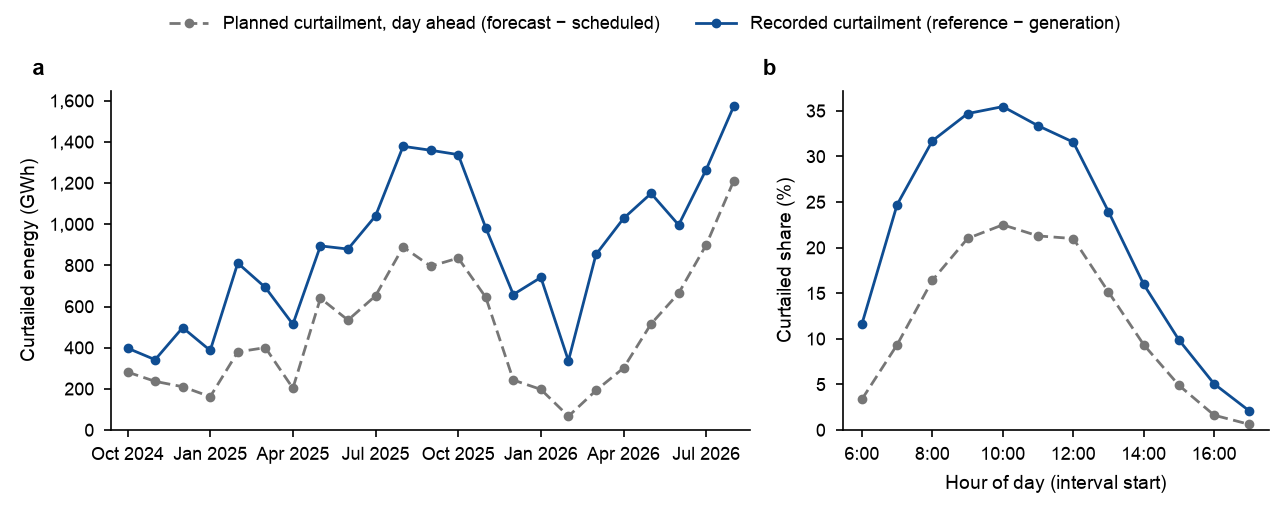

In [8]:
fig, (ax_month, ax_hour) = plt.subplots(1, 2, figsize=viz.size(height_mm=62), width_ratios=[1.5, 1],
                                        layout="constrained")
line_style = dict(marker="o", markersize=2.5)

# a: energy per month
months = np.arange(len(by_month))
ax_month.plot(months, by_month["planned"], color=viz.PLANNED_COLOR, ls=(0, (4, 2)), **line_style)
ax_month.plot(months, by_month["realized"], color=viz.REALIZED_COLOR, **line_style)
viz.month_axis(ax_month, by_month.index, every=3)
ax_month.set_ylim(0, None)
ax_month.set_ylabel("Curtailed energy (GWh)")
viz.comma_axis(ax_month.yaxis)

# b: hourly profile
ax_hour.plot(by_hour.index, by_hour["planned_share"], color=viz.PLANNED_COLOR, ls=(0, (4, 2)), **line_style)
ax_hour.plot(by_hour.index, by_hour["realized_share"], color=viz.REALIZED_COLOR, **line_style)
ax_hour.set_xticks(by_hour.index[::2], [f"{h}:00" for h in by_hour.index[::2]])
ax_hour.set_xlabel("Hour of day (interval start)")
ax_hour.set_ylim(0, None)
ax_hour.set_ylabel("Curtailed share (%)")

for ax, letter in ((ax_month, "a"), (ax_hour, "b")):
    viz.panel_label(ax, letter)
legend_lines = [plt.Line2D([], [], color=viz.PLANNED_COLOR, ls=(0, (4, 2)), **line_style),
                plt.Line2D([], [], color=viz.REALIZED_COLOR, **line_style)]
fig.legend(legend_lines, ["Planned curtailment, day ahead (forecast − scheduled)",
                          "Recorded curtailment (reference − generation)"],
           loc="outside upper center", ncols=2)
viz.save(fig, "fig6_day_ahead_plan")

**Figure 6 | The ONS day-ahead plan anticipates the pattern of curtailment but underestimates its
magnitude.** **a**, Curtailed energy per month: planned in the day-ahead schedule (dashed) and recorded
(solid). **b**, Curtailed share per hour: planned, relative to the forecast, and recorded, relative to
the reference. Solar clusters with a linked plan, 6:00–17:59, Oct 2024–Aug 2026 (n = 1,057,359 30-min
intervals).

## 4. Conclusions

**The day-ahead forecast net load is the system variable most associated with curtailment (Figure 5).**
- Spearman correlation between the curtailed share (9:00–14:59) and the forecast SIN net load: −0.77, over
  the 698 days with renewable forecasts. With the scheduled load alone, −0.62; the difference corresponds
  to the wind and solar forecasts. (An earlier version of this notebook reported −0.69 and −0.53,
  computed including Apr–Sep 2024, when the forecast net load did not include the forecasts.)
- In the lowest net-load decile (~23 GW), 60% of solar energy is curtailed; in the highest (~58 GW), 11%.
- Weekends cluster in the low-net-load, high-curtailment region. This is consistent with the "Sunday"
  effect of notebook 01 being, to a large extent, a load effect.

**The ONS day-ahead plan anticipates curtailment but underestimates it (Figure 6).**
- When the plan forecasts curtailment above 5%, a curtailment event is recorded in 94% of intervals.
- 43% of intervals with a curtailment event had no relevant planned curtailment, which indicates
  decisions taken after the schedule, in real time.
- In energy, realized curtailment was 1.3 to 5.0 times the planned amount. The ratio was highest from
  Jan to Apr 2026 (3.4 to 5.0 times) and fell to 1.3 in Aug 2026.
- In the hourly profile, the plan reaches 23% at 10:00; the realized share, 35%.